In [17]:
from RamanModel import generateCurve
from HelperFunctions import downsample_and_normalize

raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
 }

target_x, target_y, params = generateCurve(raman_params, 4, resolution=1000, noise_sigma=0.5)
target_y = downsample_and_normalize(target_y, resolution=1000)

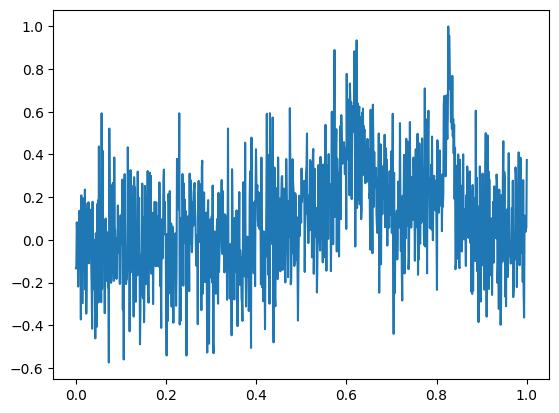

In [18]:
import matplotlib.pyplot as plt

plt.plot(target_x, target_y)

# IT'S ALIVE!!!!

In [19]:
from autoFit import autoFit

best_overall_result = autoFit(target_x, target_y, raman_params)

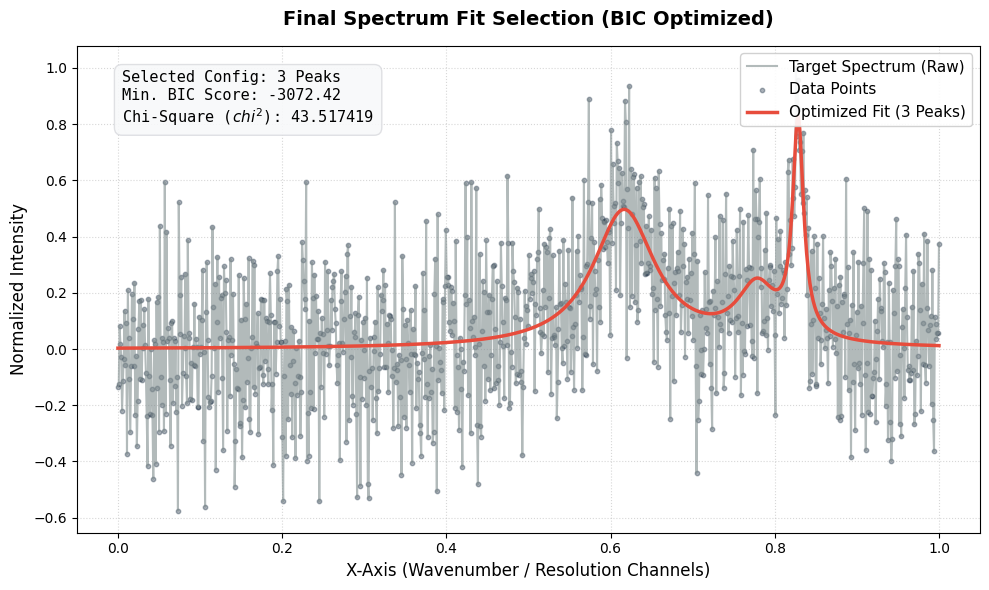

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from the result block
fitted_y = np.array(best_overall_result["fitted_values"])
chosen_peaks = best_overall_result["num_peaks"]
final_bic = best_overall_result["bic"]
final_chisqr = best_overall_result["chisqr"]

# Initialize a professional layout
plt.figure(figsize=(10, 6))

# 1. Plot the target ground truth spectrum
plt.plot(target_x, target_y, color="#7f8c8d", alpha=0.6, linewidth=1.5, label="Target Spectrum (Raw)")
plt.scatter(target_x, target_y, color="#2c3e50", s=10, alpha=0.4, label="Data Points")

# 2. Plot the master fitted curve selected by BIC
plt.plot(target_x, fitted_y, color="#e74c3c", linewidth=2.5, linestyle="-", 
         label=f"Optimized Fit ({chosen_peaks} Peaks)")

# Formatting and Styling
plt.title(f"Final Spectrum Fit Selection (BIC Optimized)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("X-Axis (Wavenumber / Resolution Channels)", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)

# Add a clean text box in the upper right quadrant with optimization details
text_stats = (f"Selected Config: {chosen_peaks} Peaks\n"
              f"Min. BIC Score: {final_bic:.2f}\n"
              f"Chi-Square ($chi^2$): {final_chisqr:.6f}")

props = dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dcdde1', alpha=0.9)
plt.gca().text(0.05, 0.95, text_stats, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

plt.legend(loc="upper right", fontsize=11, framealpha=0.9)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()


plt.show()

# Dataset Test

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_pipeline_diagnostics(pipeline_records, all_spectra_y, true_num_peaks, combinations, samples_distribution):
    """
    Plots Chi-Squared vs Noise Sigma and Chi-Squared vs True Number of Peaks.
    """
    if not pipeline_records:
        print("No records available to plot.")
        return

    # 1. Map each sample index back to its original noise sigma from the generator distribution
    sample_to_sigma = {}
    current_global_idx = 0
    for (num_peaks, sigma), count in zip(combinations, samples_distribution):
        for _ in range(count):
            sample_to_sigma[current_global_idx] = sigma
            current_global_idx += 1

    # 2. Build a structured pandas DataFrame from your pipeline outcomes
    plot_data = []
    for record in pipeline_records:
        idx = record["sample_index"]
        plot_data.append({
            "Chi_Squared": record["chisqr"],
            "True_Peaks": record["true_peaks"],
            "Predicted_Peaks": record["predicted_peaks"],
            "Noise_Sigma": sample_to_sigma.get(idx, 0.0) # Retrieve corresponding noise level
        })
    
    df = pd.DataFrame(plot_data)

    # Set up a clean, publication-ready style
    sns.set_theme(style="whitegrid")
    
    # --- GRAPH 1: Chi-Squared by Noise Sigma ---
    plt.figure(figsize=(9, 6))
    # Boxplot + Stripplot combo shows both distribution trends and individual data points clearly
    sns.boxplot(x="Noise_Sigma", y="Chi_Squared", data=df, color="#3498db", width=0.4, fliersize=0)
    sns.stripplot(x="Noise_Sigma", y="Chi_Squared", data=df, color="#2c3e50", size=5, alpha=0.4, jitter=0.15)
    
    plt.title("Optimization Residual ($chi^2$) vs. Spectral Noise Level", fontsize=13, pad=15, fontweight='bold')
    plt.xlabel("Noise Sigma ($sigma$)", fontsize=11)
    plt.ylabel("Final Chi-Squared ($chi^2$)", fontsize=11)
    plt.tight_layout()
    plt.savefig("chisqr_by_noise.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved noise diagnostic graph to 'chisqr_by_noise.png'")

    # --- GRAPH 2: Chi-Squared by Number of Peaks ---
    plt.figure(figsize=(9, 6))
    # Using a violin plot here lets you see if higher peak configurations introduce wider optimization variance
    sns.violinplot(x="True_Peaks", y="Chi_Squared", data=df, color="#e74c3c", inner="quart")
    sns.stripplot(x="True_Peaks", y="Chi_Squared", data=df, color="#2c3e50", size=4, alpha=0.3, jitter=0.2)
    
    plt.title("Optimization Residual ($chi^2$) vs. True Peak Complexity", fontsize=13, pad=15, fontweight='bold')
    plt.xlabel("True Number of Peaks ($N$)", fontsize=11)
    plt.ylabel("Final Chi-Squared ($chi^2$)", fontsize=11)
    plt.tight_layout()
    plt.savefig("chisqr_by_peaks.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved peak count diagnostic graph to 'chisqr_by_peaks.png'")

Opening data archive: training_data/pipeline_test.h5...
Loaded 300 samples for pipeline validation.


>>> PROCESSING SPECTRUM 1 OF 300 <<<
>>> PROCESSING SPECTRUM 2 OF 300 <<<
>>> PROCESSING SPECTRUM 3 OF 300 <<<
>>> PROCESSING SPECTRUM 4 OF 300 <<<
>>> PROCESSING SPECTRUM 5 OF 300 <<<
>>> PROCESSING SPECTRUM 6 OF 300 <<<
>>> PROCESSING SPECTRUM 7 OF 300 <<<
>>> PROCESSING SPECTRUM 8 OF 300 <<<
>>> PROCESSING SPECTRUM 9 OF 300 <<<
>>> PROCESSING SPECTRUM 10 OF 300 <<<
>>> PROCESSING SPECTRUM 11 OF 300 <<<
>>> PROCESSING SPECTRUM 12 OF 300 <<<
>>> PROCESSING SPECTRUM 13 OF 300 <<<
>>> PROCESSING SPECTRUM 14 OF 300 <<<
>>> PROCESSING SPECTRUM 15 OF 300 <<<
>>> PROCESSING SPECTRUM 16 OF 300 <<<
>>> PROCESSING SPECTRUM 17 OF 300 <<<
>>> PROCESSING SPECTRUM 18 OF 300 <<<
>>> PROCESSING SPECTRUM 19 OF 300 <<<
>>> PROCESSING SPECTRUM 20 OF 300 <<<
>>> PROCESSING SPECTRUM 21 OF 300 <<<
>>> PROCESSING SPECTRUM 22 OF 300 <<<
>>> PROCESSING SPECTRUM 23 OF 300 <<<
>>> PROCESSING SPECTRUM 24 OF 300

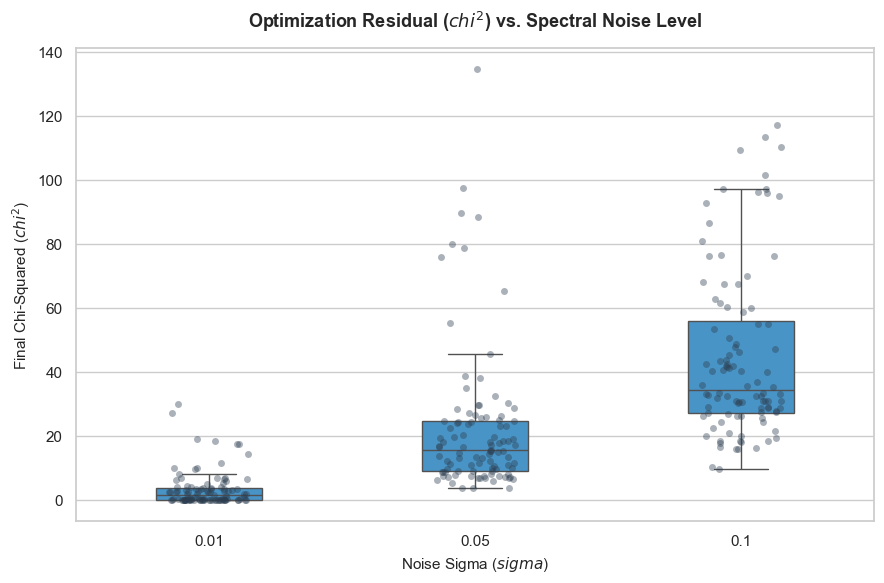

Saved noise diagnostic graph to 'chisqr_by_noise.png'


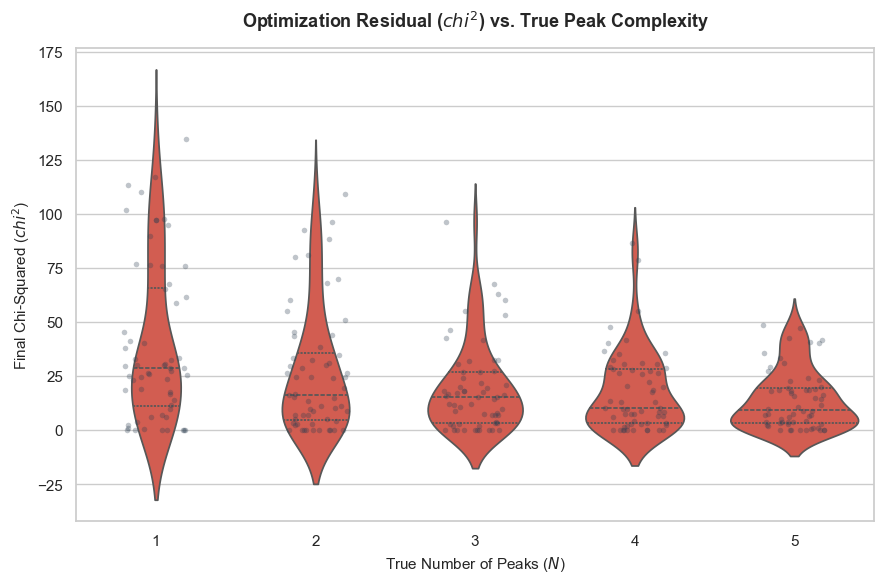

Saved peak count diagnostic graph to 'chisqr_by_peaks.png'


In [100]:
import h5py
import numpy as np
import json
import itertools
from autoFit import autoFit
# Importing your JIT composite model to re-generate ideal reference baselines
from AdaptiveKnn import composite_lorentzian_model

# 1. Define configuration and paths
H5_FILENAME = "training_data/pipeline_test.h5"

raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

if __name__ == "__main__":
    print(f"Opening data archive: {H5_FILENAME}...")
    
    # 2. Extract arrays from the HDF5 archive (including peak_parameters now)
    with h5py.File(H5_FILENAME, "r") as hf:
        target_x = hf["x_values"][:]         # 1D array of wavenumbers/channels
        all_spectra_y = hf["y_values"][:]     # 2D matrix [samples, resolution]
        true_num_peaks = hf["num_peaks"][:]   # 1D array of ground-truth counts
        # Variable-length JSON strings containing original structural parameters
        raw_peak_params = hf["peak_parameters"][:] 
        
    total_samples = all_spectra_y.shape[0]
    print(f"Loaded {total_samples} samples for pipeline validation.\n")
    
    pipeline_records = []
    
    # 3. Main processing loop over every spectrum
    for i in range(total_samples):
        print(f"\n>>> PROCESSING SPECTRUM {i+1} OF {total_samples} <<<", end="\r", flush=True)
        #print(f"Ground Truth Label: {true_num_peaks[i]} Peaks")
        
        current_target_y = all_spectra_y[i]
        
        # Run the complete multi-scale CNN + Parallel BIC Fit optimization pipeline
        best_overall_result = autoFit(
            target_x=target_x,
            target_y=current_target_y,
            base_parameters=raman_params,
        )
        
        # 4. Save and inspect individual outcomes
        if best_overall_result is not None:
            predicted_count = best_overall_result["num_peaks"]
            bic_score = best_overall_result["bic"]
            chisqr_val = best_overall_result["chisqr"]
            
            # --- NEW: Threshold Evaluation Strategy ---
            # Parse the ground truth parameters from JSON to unpack keys
            parsed_params = json.loads(raw_peak_params[i])

            # CRITICAL FIX: If parsed_params is a list, flatten it into a prefixed dict
            if isinstance(parsed_params, list):
                flattened_dict = {}
                for peak_idx, peak_data in enumerate(parsed_params):
                    pref = f"p{peak_idx}_"
                    # Maps your raw dictionary keys to the required lmfit prefixes
                    # Adjust 'center', 'gamma', and 'amplitude' if your generator uses different key names!
                    flattened_dict[f"{pref}x0"] = peak_data.get("center", peak_data.get("x0"))
                    flattened_dict[f"{pref}gamma"] = peak_data.get("gamma")
                    flattened_dict[f"{pref}maximum"] = peak_data.get("amplitude", peak_data.get("maximum"))
                parsed_params = flattened_dict
                
            # Reconstruct the noise-free ideal reference array baseline profile
            y_ideal = composite_lorentzian_model(target_x, **parsed_params)
            
            # Compute f* baseline limit metric (Distance from raw noisy line to true ideal profile)
            f_star = np.dot(current_target_y - y_ideal, current_target_y - y_ideal)
            success_threshold = f_star + 1e-6
            
            # Determine if your optimized fit is within the allowable envelope bounds
            passed_threshold = bool(chisqr_val <= success_threshold)
            
            # Record structural information for validation analytics
            record = {
                "sample_index": i,
                "true_peaks": int(true_num_peaks[i]),
                "predicted_peaks": int(predicted_count),
                "bic": float(bic_score),
                "chisqr": float(chisqr_val),
                "optimized_parameters": best_overall_result["best_values"],
                "fitted_values": best_overall_result["fitted_values"],
                "passed_threshold": passed_threshold # Save outcome flag
            }
            pipeline_records.append(record)
            
            # Quick console diagnostics output
            is_correct = (predicted_count == true_num_peaks[i])
            status_tag = "SUCCESS (Exact Match)" if is_correct else "MISMATCH"
            thresh_tag = "PASSED" if passed_threshold else "FAILED"
            
            #print(f"Result Status: {status_tag} -> Chosen: {predicted_count} peaks (BIC: {bic_score:.2f})")
            #print(f"Threshold Test: {thresh_tag} -> Residual: {chisqr_val:.6f} <= Limit: {success_threshold:.6f}")
        else:
            print(f"Result Status: FAILED -> Auto-fit processing encountered an exception for sample {i}.")

    # --- End of processing summary ---
    print("\n" + "="*40)
    print("PIPELINE PROCESSING COMPLETE")
    print(f"Successfully optimized {len(pipeline_records)}/{total_samples} spectra.")
    
    # Calculate global pipeline performance metrics
    if len(pipeline_records) > 0:
        exact_matches = sum(1 for r in pipeline_records if r["true_peaks"] == r["predicted_peaks"])
        under_by_one = sum(1 for r in pipeline_records if r["true_peaks"] - r["predicted_peaks"] == 1)
        
        # --- NEW: Aggregate Global Threshold Metrics ---
        threshold_passes = sum(1 for r in pipeline_records if r["passed_threshold"])
        threshold_rate = threshold_passes / total_samples
        
        print(f"Pipeline Exact Accuracy:     {exact_matches / total_samples:.2%}")
        print(f"Pipeline -1 Accuracy (Safe):  {(exact_matches + under_by_one) / total_samples:.2%}")
        print(f"Pipeline Threshold Pass Rate: {threshold_rate:.2%}") # Added final display
    print("="*40)

    # Re-calculate combination balance parameters
    peak_counts = [1, 2, 3, 4, 5] 
    noise_sigmas = [0.01, 0.05, 0.1] 
    
    combinations = list(itertools.product(peak_counts, noise_sigmas))
    samples_per_combo = total_samples // len(combinations)
    remainder = total_samples % len(combinations)
    samples_distribution = [samples_per_combo + (1 if i < remainder else 0) for i in range(len(combinations))]

    # Call the diagnostic plotting block
    plot_pipeline_diagnostics(
        pipeline_records=pipeline_records,
        all_spectra_y=all_spectra_y,
        true_num_peaks=true_num_peaks,
        combinations=combinations,
        samples_distribution=samples_distribution
    )


Selecting 4 random samples for visual auditing...
Saved audit plot 1/4 to 'final_samples/audit_sample_idx_35.png'


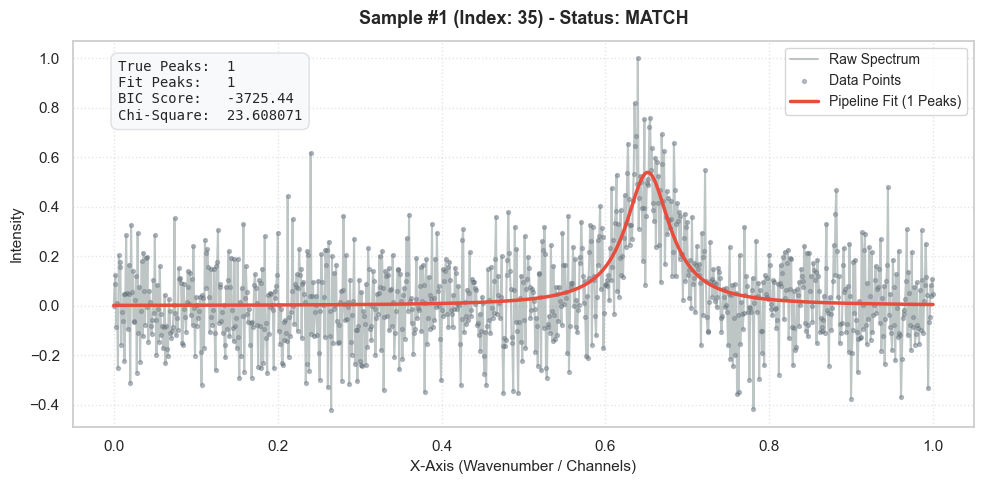

Saved audit plot 2/4 to 'final_samples/audit_sample_idx_209.png'


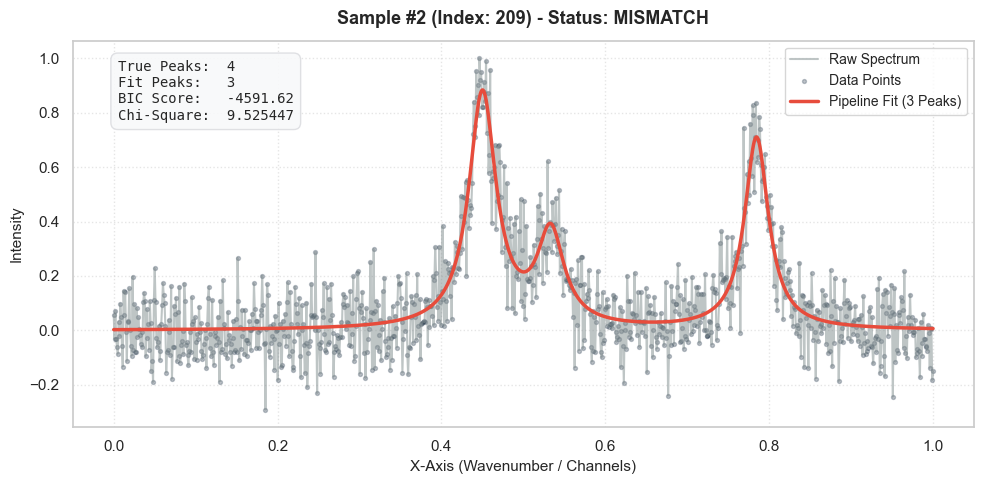

Saved audit plot 3/4 to 'final_samples/audit_sample_idx_116.png'


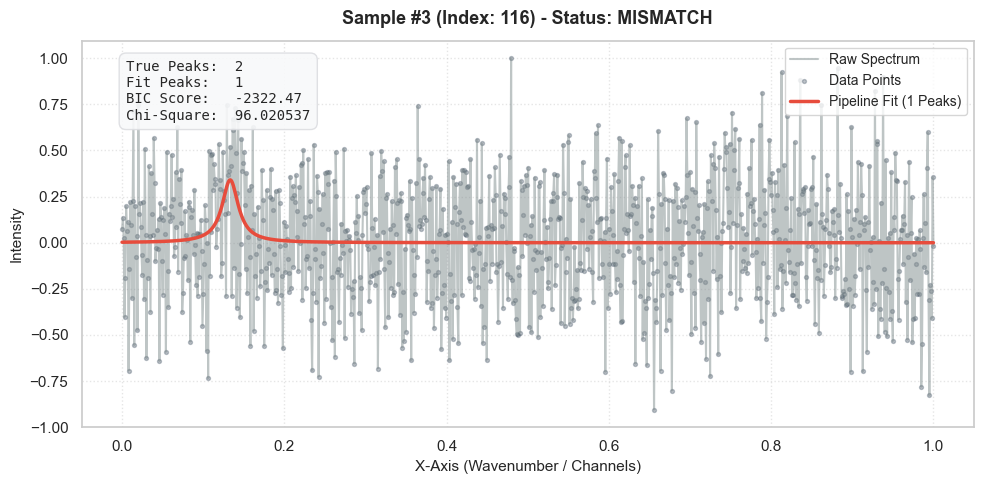

Saved audit plot 4/4 to 'final_samples/audit_sample_idx_72.png'


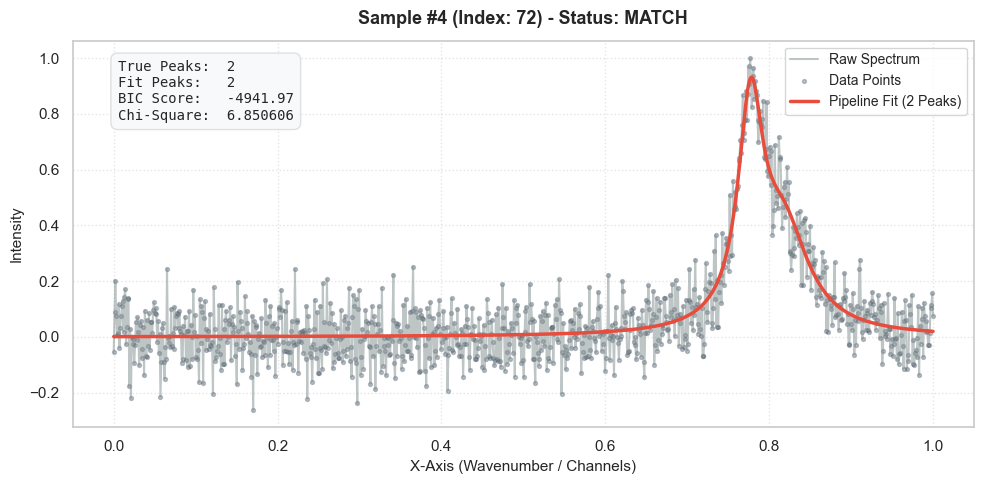

In [102]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have at least 4 successful records to choose from
if len(pipeline_records) >= 4:
    print("\nSelecting 4 random samples for visual auditing...")
    
    # 1. Randomly sample 4 unique record dictionaries from your pipeline results
    random_samples = random.sample(pipeline_records, k=4)
    
    # 2. Loop through the selected samples and plot them
    for sample_rank, record in enumerate(random_samples, 1):
        idx = record["sample_index"]
        true_peaks = record["true_peaks"]
        pred_peaks = record["predicted_peaks"]
        bic_score = record["bic"]
        chisqr_val = record["chisqr"]
        
        # Extract the true raw y-intensity array from your loaded h5 data matrix
        raw_y = all_spectra_y[idx]
        
        # Access the optimized fit curve from the specific process result block
        # (Assuming you modified autoFit to pass this or you recompute it)
        # Note: If 'fitted_values' isn't in your recorded summary, ensure your autoFit 
        # loop passes it to the 'pipeline_records' dictionary!
        if "fitted_values" in record:
            fitted_y = np.array(record["fitted_values"])
        else:
            # Fallback if you didn't append the fitted array to the record dictionary yet:
            # We can recompute it using the composite model and the optimized parameters
            from AdaptiveKnn import composite_lorentzian_model
            fitted_y = composite_lorentzian_model(target_x, **record["optimized_parameters"])
        
        # 3. Initialize the plot layout
        plt.figure(figsize=(10, 5))
        
        # Plot the ground truth raw spectrum points and line
        plt.plot(target_x, raw_y, color="#7f8c8d", alpha=0.5, linewidth=1.5, label="Raw Spectrum")
        plt.scatter(target_x, raw_y, color="#2c3e50", s=8, alpha=0.3, label="Data Points")
        
        # Overlay the winning multi-Lorentzian fit curve
        plt.plot(target_x, fitted_y, color="#e74c3c", linewidth=2.5, 
                 label=f"Pipeline Fit ({pred_peaks} Peaks)")
        
        # Dynamic styling and text details
        match_status = "MATCH" if true_peaks == pred_peaks else "MISMATCH"
        plt.title(f"Sample #{sample_rank} (Index: {idx}) - Status: {match_status}", 
                  fontsize=13, pad=12, fontweight='bold')
        plt.xlabel("X-Axis (Wavenumber / Channels)", fontsize=11)
        plt.ylabel("Intensity", fontsize=11)
        
        # Build diagnostic info metadata box
        text_stats = (f"True Peaks:  {true_peaks}\n"
                      f"Fit Peaks:   {pred_peaks}\n"
                      f"BIC Score:   {bic_score:.2f}\n"
                      f"Chi-Square:  {chisqr_val:.6f}")
        
        props = dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dcdde1', alpha=0.9)
        plt.gca().text(0.05, 0.95, text_stats, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=props, fontfamily='monospace')
        
        plt.legend(loc="upper right", fontsize=10)
        plt.grid(True, linestyle=":", alpha=0.5)
        plt.tight_layout()
        
        # 4. Save each image with a descriptive filename using the sample index
        filename = f"final_samples/audit_sample_idx_{idx}.png"
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Saved audit plot {sample_rank}/4 to '{filename}'")
        
        plt.show()
else:
    print(f"Skipping random sampling: Pipeline only successfully fitted {len(pipeline_records)}/4 spectra.")

# Real Samples - Calcium Carbonate

Spectrum plot cleanly rendered and saved to 'calcium_carbonate_raw_spectrum.png'


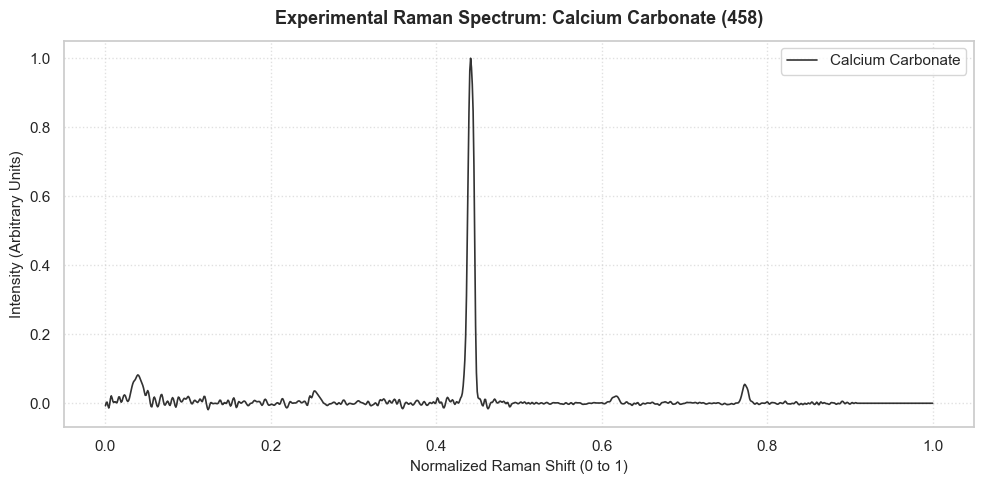

Total processed data points: 1000


In [30]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from HelperFunctions import downsample_and_normalize

data = []

with open('real_examples/csvs/CalciumCarbonate-458.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[:1816]
target_y = y[:1816]

target_y = downsample_and_normalize(target_y, resolution=1000)
target_x = np.linspace(0, 1, 1000)

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Carbonate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Calcium Carbonate (458)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "calcium_carbonate_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [41]:
raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

best_overall_result = autoFit(target_x, target_y, raman_params)

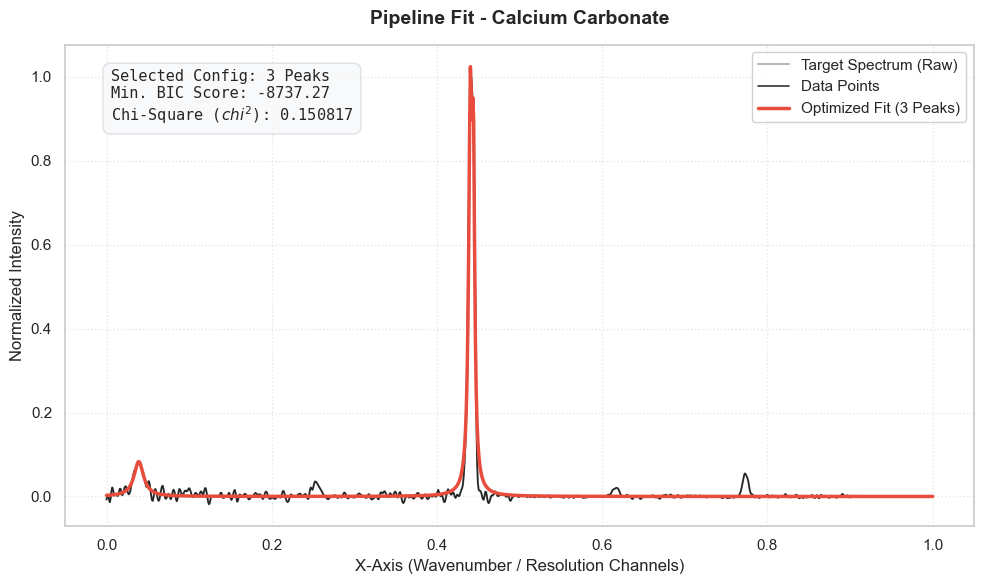

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from the result block
fitted_y = np.array(best_overall_result["fitted_values"])
chosen_peaks = best_overall_result["num_peaks"]
final_bic = best_overall_result["bic"]
final_chisqr = best_overall_result["chisqr"]

# Initialize a professional layout
plt.figure(figsize=(10, 6))

# 1. Plot the target ground truth spectrum
plt.plot(target_x, target_y, color="#7f8c8d", alpha=0.6, linewidth=1.5, label="Target Spectrum (Raw)")
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Data Points')

# 2. Plot the master fitted curve selected by BIC
plt.plot(target_x, fitted_y, color="#e74c3c", linewidth=2.5, linestyle="-", 
         label=f"Optimized Fit ({chosen_peaks} Peaks)")

# Formatting and Styling
plt.title(f"Pipeline Fit - Calcium Carbonate", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("X-Axis (Wavenumber / Resolution Channels)", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)

# Add a clean text box in the upper right quadrant with optimization details
text_stats = (f"Selected Config: {chosen_peaks} Peaks\n"
              f"Min. BIC Score: {final_bic:.2f}\n"
              f"Chi-Square ($chi^2$): {final_chisqr:.6f}")

props = dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dcdde1', alpha=0.9)
plt.gca().text(0.05, 0.95, text_stats, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

plt.legend(loc="upper right", fontsize=11, framealpha=0.9)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("calcium_carbonate_fit_pipeline.png", dpi=300, bbox_inches='tight')

plt.show()

# Real Samples - Calcium Sulfate

Spectrum plot cleanly rendered and saved to 'calcium_sulfate_raw_spectrum.png'


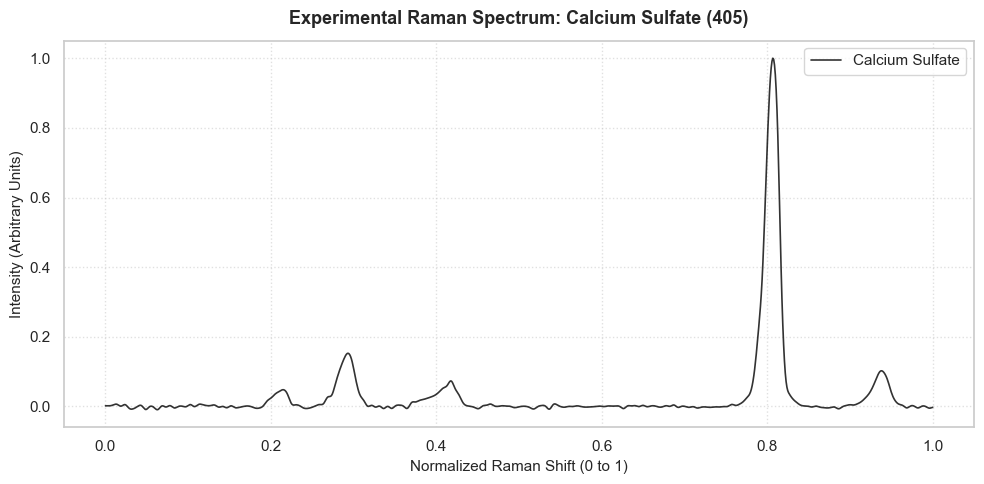

Total processed data points: 1000


In [43]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from HelperFunctions import downsample_and_normalize

data = []

with open('real_examples/csvs/CalciumSulfate_405.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[0:1000]
target_y = y[0:1000]

target_x = np.linspace(0, 1, 1000)
target_y = downsample_and_normalize(target_y, resolution=1000)

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Sulfate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Calcium Sulfate (405)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "calcium_sulfate_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [89]:
raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

best_overall_result = autoFit(target_x, target_y, raman_params)

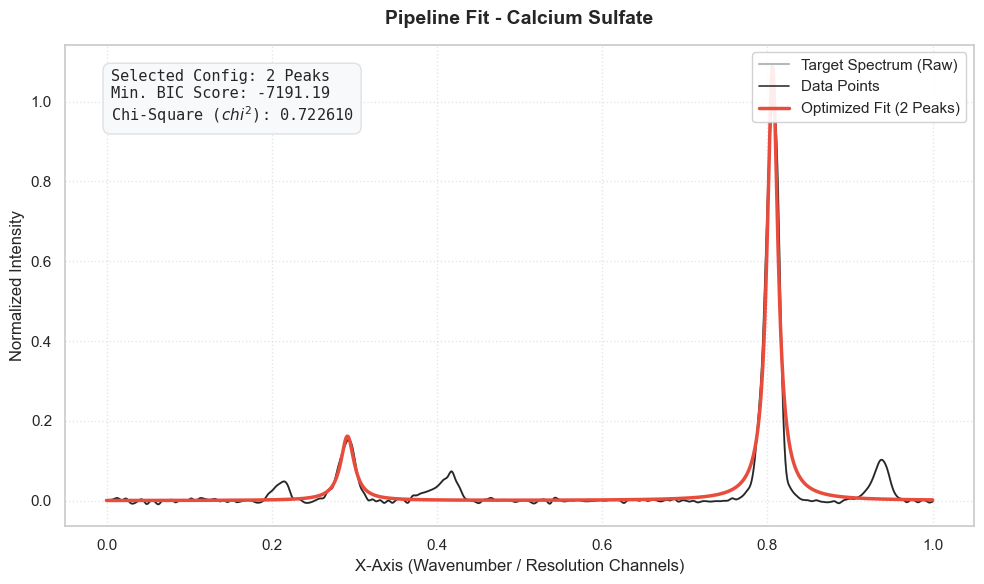

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from the result block
fitted_y = np.array(best_overall_result["fitted_values"])
chosen_peaks = best_overall_result["num_peaks"]
final_bic = best_overall_result["bic"]
final_chisqr = best_overall_result["chisqr"]

# Initialize a professional layout
plt.figure(figsize=(10, 6))

# 1. Plot the target ground truth spectrum
plt.plot(target_x, target_y, color="#7f8c8d", alpha=0.6, linewidth=1.5, label="Target Spectrum (Raw)")
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Data Points')

# 2. Plot the master fitted curve selected by BIC
plt.plot(target_x, fitted_y, color="#e74c3c", linewidth=2.5, linestyle="-", 
         label=f"Optimized Fit ({chosen_peaks} Peaks)")

# Formatting and Styling
plt.title(f"Pipeline Fit - Calcium Sulfate", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("X-Axis (Wavenumber / Resolution Channels)", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)

# Add a clean text box in the upper right quadrant with optimization details
text_stats = (f"Selected Config: {chosen_peaks} Peaks\n"
              f"Min. BIC Score: {final_bic:.2f}\n"
              f"Chi-Square ($chi^2$): {final_chisqr:.6f}")

props = dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dcdde1', alpha=0.9)
plt.gca().text(0.05, 0.95, text_stats, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

plt.legend(loc="upper right", fontsize=11, framealpha=0.9)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("calcium_sulfate_fit_pipeline.png", dpi=300, bbox_inches='tight')

plt.show()

# Iron Oxide

Spectrum plot cleanly rendered and saved to 'Olivine_raw_spectrum.png'


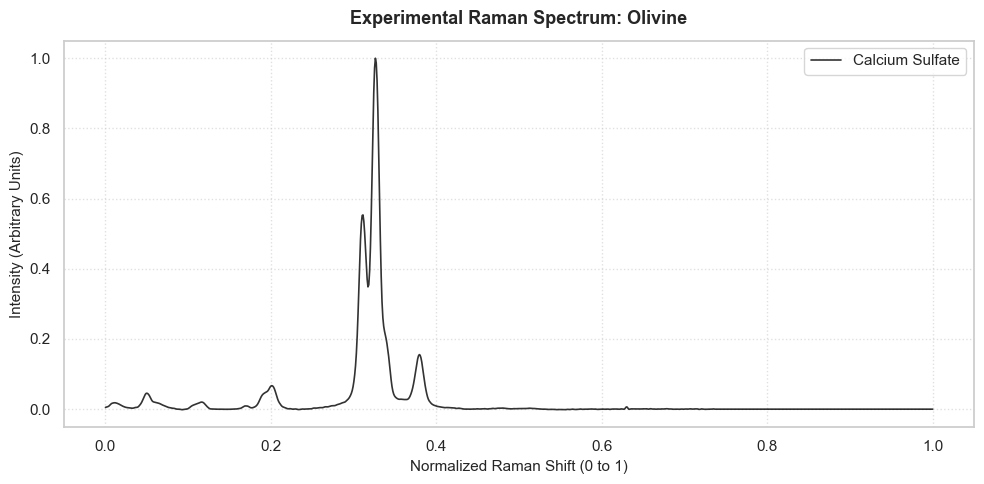

Total processed data points: 1000


In [93]:
import csv
import numpy as np
import matplotlib.pyplot as plt

data = []

with open('real_examples/csvs/Olivine_405.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[:1472]
target_y = y[:1472]

target_x = np.linspace(0, 1, 1000)
target_y = downsample_and_normalize(target_y, resolution=1000)

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Sulfate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Olivine", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "Olivine_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [94]:
raman_params = {
    "center_range": (0.05, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

best_overall_result = autoFit(target_x, target_y, raman_params)

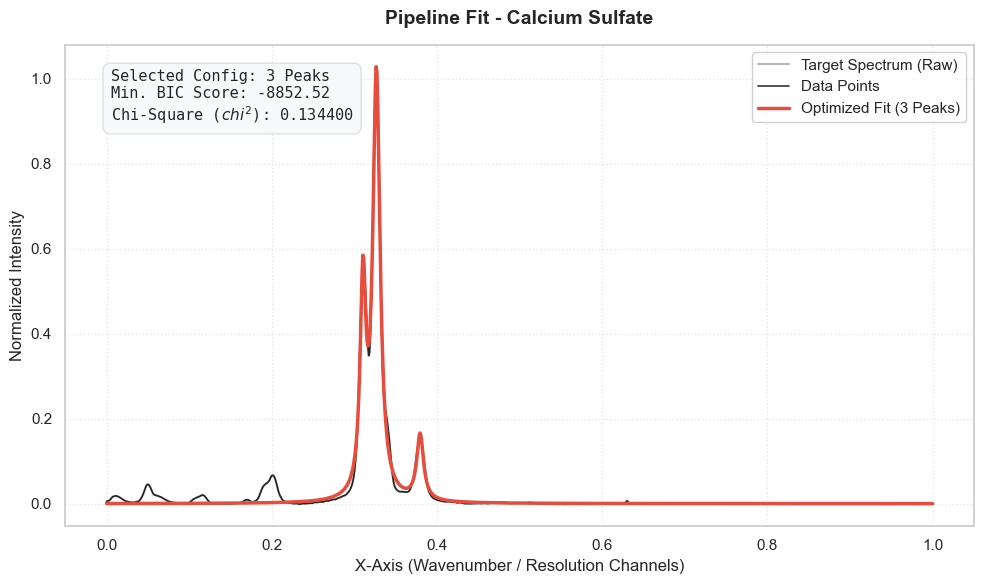

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from the result block
fitted_y = np.array(best_overall_result["fitted_values"])
chosen_peaks = best_overall_result["num_peaks"]
final_bic = best_overall_result["bic"]
final_chisqr = best_overall_result["chisqr"]

# Initialize a professional layout
plt.figure(figsize=(10, 6))

# 1. Plot the target ground truth spectrum
plt.plot(target_x, target_y, color="#7f8c8d", alpha=0.6, linewidth=1.5, label="Target Spectrum (Raw)")
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Data Points')

# 2. Plot the master fitted curve selected by BIC
plt.plot(target_x, fitted_y, color="#e74c3c", linewidth=2.5, linestyle="-", 
         label=f"Optimized Fit ({chosen_peaks} Peaks)")

# Formatting and Styling
plt.title(f"Pipeline Fit - Calcium Sulfate", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("X-Axis (Wavenumber / Resolution Channels)", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)

# Add a clean text box in the upper right quadrant with optimization details
text_stats = (f"Selected Config: {chosen_peaks} Peaks\n"
              f"Min. BIC Score: {final_bic:.2f}\n"
              f"Chi-Square ($chi^2$): {final_chisqr:.6f}")

props = dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dcdde1', alpha=0.9)
plt.gca().text(0.05, 0.95, text_stats, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

plt.legend(loc="upper right", fontsize=11, framealpha=0.9)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("olivine_fit_pipeline.png", dpi=300, bbox_inches='tight')

plt.show()